In [1]:
import pandas as pd 
df= pd.read_excel("..\Datasets\Dataset cancer\dataset.xlsx")
df

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\zgibio\AppData\Local\Temp\ipykernel_13740\3497429557.py:2: SyntaxWarning: invalid escape sequence '\D'
  df= pd.read_excel("..\Datasets\Dataset cancer\dataset.xlsx")


,Unnamed: 0,Heavy / Extreme menstrual bleeding,Menstrual pain (Dysmenorrhea),Painful / Burning pain during sex (Dyspareunia),Pelvic pain,Irregular / Missed periods,Cramping,Abdominal pain / pressure,Back pain,Painful bowel movements,...,Hormonal problems,Bloating,Feeling sick,Decreased energy / Exhaustion,Abdominal Cramps during Intercourse,Insomnia / Sleeplessness,Acne / pimples,Loss of appetite,row,label
0,Heavy / Extreme menstrual bleeding;Fatigue / C...,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,0,0,0,0,1
1,Heavy / Extreme menstrual bleeding;Nausea;Pain...,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,0,0,1,1,1
2,Fatigue / Chronic fatigue;Nausea;Bloating;Back...,0,1,0,1,1,1,0,1,0,...,0,1,1,1,0,1,0,0,2,1
3,Heavy / Extreme menstrual bleeding;Fatigue / C...,1,0,0,0,0,1,1,1,0,...,0,1,0,1,0,0,0,0,3,1
4,Fatigue / Chronic fatigue;Painful / Burning pa...,0,1,1,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,Pelvic pain;Back pain;Pain / Chronic pain;Migr...,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,881,0
882,Painful / Burning pain during sex (Dyspareunia...,0,0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,882,0
883,Cramping;Back pain;Painful bowel movements;Nau...,0,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,883,0
884,Pain / Chronic pain;Painful ovulation;Extreme ...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,884,0


In [2]:
df.drop(columns=["Unnamed: 0"] , inplace=True)
df.drop(columns=["row"] , inplace=True)

In [3]:
df_test = df.sample(n=10, random_state=42)  # 10 random rows for manual test, fix the seed with random_state

# Step 2: Remove these 10 rows from the original DataFrame
df = df.drop(df_test.index)

In [4]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

In [5]:
x = df.drop(columns=["label"]) 
y = df["label"]


In [9]:

from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Split des données
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


model = Sequential([
    Dense(64, activation='relu', input_dim=x.shape[1]),
    
    Dense(32, activation='relu'),
    
    Dense(1, activation='sigmoid')
])



# Compilation du modèle
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entraînement du modèle
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)



Epoch 1/20


c:\Users\zgibio\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5387 - loss: 0.5845 - val_accuracy: 0.7330 - val_loss: 0.4708
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7867 - loss: 0.4591 - val_accuracy: 0.8466 - val_loss: 0.3851
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8877 - loss: 0.3419 - val_accuracy: 0.8466 - val_loss: 0.3078
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9158 - loss: 0.2593 - val_accuracy: 0.8977 - val_loss: 0.2458
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9412 - loss: 0.1780 - val_accuracy: 0.8977 - val_loss: 0.2219
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9479 - loss: 0.1495 - val_accuracy: 0.9034 - val_loss: 0.2041
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9445 - loss: 0.1323 - val_accuracy: 0.8920 - val_loss: 0.1877
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9618 - loss: 0.1121 - val_accuracy: 0.9034 - val_loss: 0.1817


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Separate the features and target from df_test
X_man = df_test.drop(columns=["label"])  # features
y_man = df_test["label"]  # target label

# Step 2: Make predictions using the trained model
y_pred = model.predict(X_man)

y_pred = (y_pred > 0.5).astype(int)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


Accuracy: 1.0000


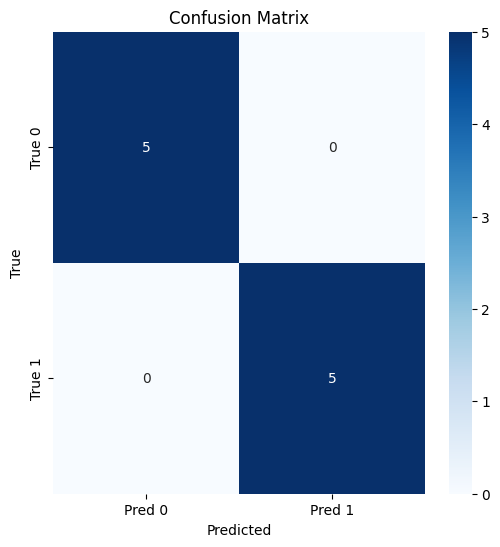

Correlation: 1.0000


In [11]:

accuracy = accuracy_score(y_man, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Step 4: Confusion Matrix
conf_matrix = confusion_matrix(y_man, y_pred)

# Plotting confusion matrix as a heatmap for better visualization
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 5: Calculate and print the correlation between actual and predicted values
correlation = np.corrcoef(y_man, y_pred.flatten())[0, 1]  # Flatten y_pred to 1D array for correlation
print(f"Correlation: {correlation:.4f}")

In [12]:
model.save('endometre_model.h5')  # Save the model as a single .h5 file
